In [2]:
epitopes_to_test = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/HLAA0201_predictions.csv')

In [3]:
epitopes_to_test['sequence'].values

array(['EVASFKQAL', 'QLSAIALGV', 'FAFRDLCIVY', ..., 'RVAVILNEF',
       'KTSICYLSF', 'KYISTSLPV'], dtype=object)

In [4]:
# generate_peptide_combinations.py
import pandas as pd

# Wild-type sequence (from 7RTD.pdb chain C)
wt_sequence = "YLQPRTFLL"
wt_length = len(wt_sequence)

# Assume you already have `epitopes_to_test` as a DataFrame
# epitopes_to_test = pd.read_csv("your_file.csv")

sequences = []

# Add the WT sequence at the beginning
sequences.append(("wildtype", wt_sequence))

# Go through all epitope variants and check length
for i, mutated_seq in enumerate(epitopes_to_test['sequence'].values, 1):
    if isinstance(mutated_seq, str) and len(mutated_seq) == wt_length:
        sequences.append((f"peptide_{i}", mutated_seq))
    else:
        print(f"⚠️ Skipping sequence at index {i} — '{mutated_seq}' (length {len(mutated_seq) if isinstance(mutated_seq, str) else 'INVALID'})")

# Write to FASTA
with open("/clusterfs/nilah/sergio/structevo/structural-evolution/peptide_hlaa0201_combinations.fasta", "w") as f:
    for name, seq in sequences:
        f.write(f">{name}\n{seq}\n")

print(f"✅ Saved {len(sequences)} valid peptide sequences (including WT).")


⚠️ Skipping sequence at index 3 — 'FAFRDLCIVY' (length 10)
⚠️ Skipping sequence at index 9 — 'SEYRHYCYSL' (length 10)
⚠️ Skipping sequence at index 11 — 'GRAKLLGAEEK' (length 11)
⚠️ Skipping sequence at index 12 — 'RAKLLGAEEK' (length 10)
⚠️ Skipping sequence at index 15 — 'GLAKLLGAEEK' (length 11)
⚠️ Skipping sequence at index 16 — 'LAKLLGAEEK' (length 10)
⚠️ Skipping sequence at index 19 — 'KAFQLTPIAV' (length 10)
⚠️ Skipping sequence at index 20 — 'DEFVVVTV' (length 8)
⚠️ Skipping sequence at index 26 — 'KAFQLTPIAV' (length 10)
⚠️ Skipping sequence at index 27 — 'DEFVVVTV' (length 8)
⚠️ Skipping sequence at index 28 — 'LEDKAFQL' (length 8)
⚠️ Skipping sequence at index 29 — 'ELPDEFVVVTV' (length 11)
⚠️ Skipping sequence at index 31 — 'EILDITPCSFG' (length 11)
⚠️ Skipping sequence at index 32 — 'EILDITPCSF' (length 10)
⚠️ Skipping sequence at index 34 — 'EEFEPSTQYEY' (length 11)
⚠️ Skipping sequence at index 37 — 'GRAKLLGAEEK' (length 11)
⚠️ Skipping sequence at index 38 — 'RAKLLGAEE

In [1]:
import pandas as pd
epitope_mt = pd.read_csv('scores.txt')

In [2]:
import seaborn as sns

In [4]:
import pandas as pd

# Load your data (assuming it's already in a DataFrame called epitope_mt)
epitope_wt = list("YLQPRTFLL")  # Convert wild-type epitope to list for mutation

def reconstruct_mutant(row):
    if row['seqid'] == 'wt':
        return ''.join(epitope_wt)
    
    mutation = row['seqid']
    orig_res = mutation[0]
    pos = int(mutation[1:-1]) - 1  # Convert to 0-based index
    new_res = mutation[-1]
    
    mutated_seq = epitope_wt.copy()
    mutated_seq[pos] = new_res
    return ''.join(mutated_seq)

# Apply to your DataFrame
epitope_mt['mutated_sequence'] = epitope_mt.apply(reconstruct_mutant, axis=1)

In [8]:
epitope_mt.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/epitope_mt.csv', index=False)

In [18]:
epitope_mt['site'] = epitope_mt['seqid'].apply(lambda x: x[1])

In [24]:
epitope_mt = epitope_mt[epitope_mt['site'] !='t']

In [27]:
epitope_mt['site'] = epitope_mt['site'].astype(int)
epitope_mt[' log_likelihood_target'] = epitope_mt[' log_likelihood_target'].astype(float)

/tmp/ipykernel_330253/4165999269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epitope_mt['site'] = epitope_mt['site'].astype(int)
/tmp/ipykernel_330253/4165999269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epitope_mt[' log_likelihood_target'] = epitope_mt[' log_likelihood_target'].astype(float)


<Axes: xlabel='site', ylabel=' log_likelihood_target'>

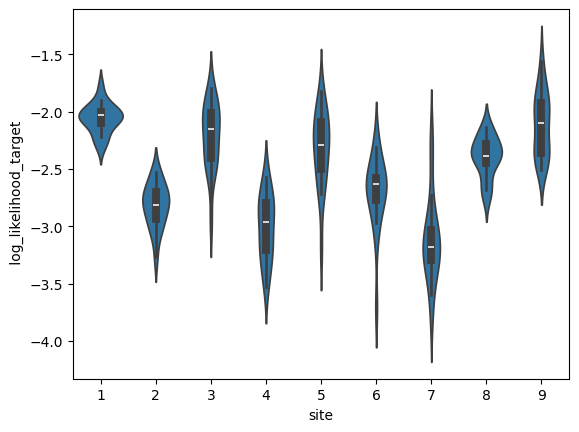

In [28]:
sns.violinplot(data=epitope_mt, x='site', y=' log_likelihood_target' ) # 3, inner='quartile')